# Function 5: Yield in a Chemical Reaction
This time you are trying to optimise another four-dimensional black-box. It corresponds to the yield of a chemical process after processing in some factory. This type of process tends to be unimodal. Try to find the combination of chemicals that maximizes the yield!

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm

In [8]:
def load_inputs(file_path):
    with open(file_path, "r") as f:
        content = f.read()

    # Make the file a proper list of lists
    content = "[" + content.replace("]\n[", "],[") + "]"

    # Safe eval with restricted globals
    return eval(content, {"array": np.array})


def load_outputs(file_path):
    with open(file_path, "r") as f:
        content = f.read()

    content = "[" + content.replace("]\n[", "],[") + "]"

    return eval(content, {"np": np})


def get_input_points(function_number, file_path="../inputs.txt"):
    if not 1 <= function_number <= 8:
        raise ValueError("Function number must be between 1 and 8")

    data = load_inputs(file_path)
    index = function_number - 1

    inputs = [dataset[index] for dataset in data]
    return np.array(inputs)


def get_output_points(function_number, file_path="../outputs.txt"):
    if not 1 <= function_number <= 8:
        raise ValueError("Function number must be between 1 and 8")

    data = load_outputs(file_path)
    index = function_number - 1

    outputs = [row[index] for row in data]
    return np.array(outputs)

# Load inputs
X = np.load(r'initial_inputs.npy')
y = np.load(r'initial_outputs.npy')


# Get input and outputs from submissions
inputs_array = get_input_points(5)
outputs_array = get_output_points(5)


# Append inputs_f1_array to X
X = np.vstack((X, inputs_array))

# Append outputs_f1_array to Y
y = np.hstack((y, outputs_array))

print("New shape of X:", X.shape)
print("New shape of Y:", y.shape)

New shape of X: (32, 4)
New shape of Y: (32,)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Current best point: [0.193486 0.949941 0.947869 1.      ]
Current best output: 3229.1762655077555
Candidate range min: [0.1734917  0.92958253 0.900517   0.96243068]
Candidate range max: [0.23487389 0.97820805 0.96786011 1.        ]


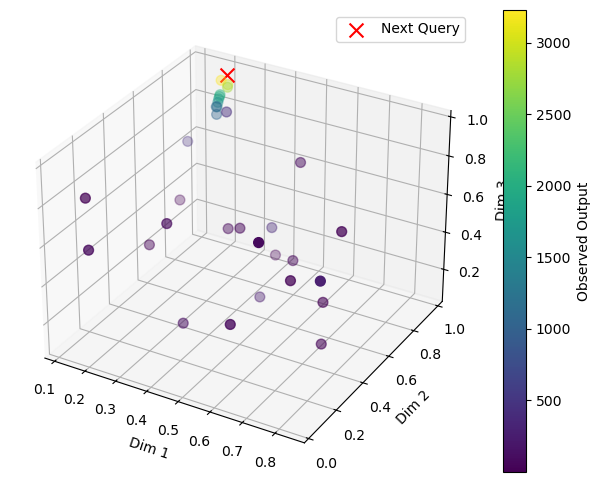

Next Query Point (4D): 0.205624-0.969307-0.967528-1.000000


In [9]:

# Fit GP
kernel = C(1.0, (1e-3, 1e4)) * RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-3, 5.0))
gpr = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=5,
    random_state=42,
)
gpr.fit(X, y)

# -----------------------------
# Current best point
# -----------------------------
rng = np.random.default_rng(42)
best_index = np.argmax(y)
best_point = X[best_index]
print("Current best point:", best_point)
print("Current best output:", y[best_index])

# -----------------------------
# Local trust-region sampling around the top 3 points
# -----------------------------
top_indices = np.argsort(y)[-3:]
top_points = X[top_indices]
radius = 0.02
local_clouds = []
for point in top_points:
    local_clouds.append(point + rng.uniform(-radius, radius, size=(4000, 4)))

X_candidates = np.vstack(local_clouds)
X_candidates = np.clip(X_candidates, 0.0, 1.0)
print("Candidate range min:", X_candidates.min(axis=0))
print("Candidate range max:", X_candidates.max(axis=0))

# Predict GP and use a mild UCB score to keep exploiting the improving region.
mean, std = gpr.predict(X_candidates, return_std=True)
ucb = mean + 0.4 * std

# Select next query
next_query_index = np.argmax(ucb)
next_query = X_candidates[next_query_index]

# -----------------------------
# 3D Visualization (first 3 dims)
# -----------------------------
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X[:,0], X[:,1], X[:,2], c=y, cmap='viridis', s=50)
ax.scatter(next_query[0], next_query[1], next_query[2], marker='x', color='red', s=100, label='Next Query')
ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")
ax.set_zlabel("Dim 3")
plt.colorbar(sc, label='Observed Output')
ax.legend()
plt.show()

# -----------------------------
# Output next query point
# -----------------------------
formatted_next_query = f"{next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}"
print("Next Query Point (4D):", formatted_next_query)